In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [7]:
master = pd.read_csv("../data/clean/meltpool_master_with_VED.csv")
master.head()
print("Loaded master dataset.")
print("Shape:", master.shape)
print("Columns:", master.columns.tolist())


Loaded master dataset.
Shape: (1012, 11)
Columns: ['material', 'P_W', 'v_mm_per_s', 'melt_width_um', 'melt_depth_um', 'LED_J_per_mm', 'norm_width', 'norm_depth', 'h_mm', 't_mm', 'VED_J_per_mm3']


In [8]:
material_to_id = {"316L": 0, "IN718": 1, "Ti64": 2}
master["material_id"] = master["material"].map(material_to_id)

print("Material encoding applied:")
print(master[["material", "material_id"]].head())

# Numeric feature columns (excluding targets)
numeric_features = [
    "P_W",
    "v_mm_per_s",
    "h_mm",
    "t_mm",
    "LED_J_per_mm",
    "VED_J_per_mm3",
]

# Targets
target_cols = ["melt_width_um", "melt_depth_um"]

# Extract X and y
X_num = master[numeric_features].values
mat_id = master["material_id"].values
y = master[target_cols].values

print("X_num shape:", X_num.shape)
print("mat_id shape:", mat_id.shape)
print("y shape:", y.shape)


Material encoding applied:
  material  material_id
0     316L            0
1     316L            0
2     316L            0
3     316L            0
4     316L            0
X_num shape: (1012, 6)
mat_id shape: (1012,)
y shape: (1012, 2)


In [9]:
print("Unique materials & counts:")
print(master["material"].value_counts())

print("\nMaterial ID distribution:")
print(master["material_id"].value_counts())


Unique materials & counts:
material
Ti64     626
IN718    342
316L      44
Name: count, dtype: int64

Material ID distribution:
material_id
2    626
1    342
0     44
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define feature groups again for clarity
numeric_feature_cols = ["P_W", "v_mm_per_s", "LED_J_per_mm", "norm_width", "norm_depth", "VED_J_per_mm3"]
target_cols = ["melt_width_um", "melt_depth_um"]

# Convert to numpy arrays
X_num = master[numeric_feature_cols].values
mat_id = master["material_id"].values
y = master[target_cols].values

# ---- Train-test split ----
X_num_train, X_num_test, mat_id_train, mat_id_test, y_train, y_test = train_test_split(
    X_num, mat_id, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# ---- Scale numeric features ----
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

print("Train num shape:", X_num_train_scaled.shape)
print("Test num shape:", X_num_test_scaled.shape)
print("Train materials:", np.unique(mat_id_train, return_counts=True))
print("Test materials:", np.unique(mat_id_test, return_counts=True))


Train num shape: (809, 6)
Test num shape: (203, 6)
Train materials: (array([0, 1, 2]), array([ 38, 271, 500]))
Test materials: (array([0, 1, 2]), array([  6,  71, 126]))


In [ ]:
from sklearn.model_selection import train_test_split


# TRAIN / TEST SPLIT

X_train_num, X_test_num, mat_id_train, mat_id_test, y_train, y_test = train_test_split(
    X_num,
    mat_id,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train num shape:", X_train_num.shape)
print("Test num shape:", X_test_num.shape)

print("\nTrain materials:", 
      (np.unique(mat_id_train, return_counts=True)))
print("Test materials:", 
      (np.unique(mat_id_test, return_counts=True)))


Train num shape: (809, 6)
Test num shape: (203, 6)

Train materials: (array([0, 1, 2]), array([ 38, 271, 500]))
Test materials: (array([0, 1, 2]), array([  6,  71, 126]))


In [ ]:
from sklearn.preprocessing import StandardScaler
import torch


scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

print("Scaled train shape:", X_train_num_scaled.shape)
print("Scaled test shape:", X_test_num_scaled.shape)


# 2. CONVERT TO TORCH TENSORS

X_train_num_t = torch.tensor(X_train_num_scaled, dtype=torch.float32)
X_test_num_t  = torch.tensor(X_test_num_scaled, dtype=torch.float32)

mat_id_train_t = torch.tensor(mat_id_train, dtype=torch.long)
mat_id_test_t  = torch.tensor(mat_id_test, dtype=torch.long)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

# Quick shape sanity check
X_train_num_t.shape, mat_id_train_t.shape, y_train_t.shape


Scaled train shape: (809, 6)
Scaled test shape: (203, 6)


(torch.Size([809, 6]), torch.Size([809]), torch.Size([809, 2]))

In [ ]:
from torch.utils.data import Dataset, DataLoader


# Custom Dataset Class

class MeltPoolDataset(Dataset):
    def __init__(self, X_num, mat_id, y):
        self.X_num = X_num
        self.mat_id = mat_id
        self.y = y

    def __len__(self):
        return self.X_num.shape[0]

    def __getitem__(self, idx):
        return {
            "X_num": self.X_num[idx],
            "mat_id": self.mat_id[idx],
            "y": self.y[idx],
        }


# Create dataset objects

train_ds = MeltPoolDataset(X_train_num_t, mat_id_train_t, y_train_t)
test_ds  = MeltPoolDataset(X_test_num_t, mat_id_test_t, y_test_t)

# ---------------------------
# DataLoaders
# ---------------------------
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))


Train batches: 26
Test batches: 7


In [ ]:
import torch
import torch.nn as nn

class MeltPoolSurrogate(nn.Module):
    def __init__(
        self,
        num_numeric_features: int,
        num_materials: int = 3,
        emb_dim: int = 3,          
        hidden_sizes=(64, 64),     
        dropout: float = 0.10      
    ):
        super().__init__()

        
        # MATERIAL EMBEDDING LAYER
        
        self.material_emb = nn.Embedding(num_materials, emb_dim)

        
        # MLP for melt-pool prediction
       
        layers = []
        input_dim = num_numeric_features + emb_dim

        in_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h

        # final layer → predict width & depth
        layers.append(nn.Linear(in_dim, 2))

        self.mlp = nn.Sequential(*layers)

    def forward(self, X_num, mat_id):
        # embedding lookup
        mat_vec = self.material_emb(mat_id)     

        # concatenate numeric + embedding
        x = torch.cat([X_num, mat_vec], dim=1)

        # forward pass
        return self.mlp(x)


In [15]:
model = MeltPoolSurrogate(num_numeric_features=6)
model


MeltPoolSurrogate(
  (material_emb): Embedding(3, 3)
  (mlp): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


# DEVICE SETUP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)


# MODEL INIT

num_numeric_features = X_train_num_t.shape[1]

model = MeltPoolSurrogate(
    num_numeric_features=num_numeric_features,
    num_materials=3,
    emb_dim=3,
    hidden_sizes=(64, 64),
    dropout=0.10
).to(device)


# OPTIMIZER + LOSS + L2

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4   # L2 regularization
)

criterion = nn.MSELoss()


# EARLY STOPPING SETTINGS

best_val_loss = float("inf")
patience = 20
patience_counter = 0
checkpoint_path = "best_meltpool_surrogate.pt"


# TRAINING LOOP

epochs = 200
train_losses = []
val_losses = []

for epoch in range(epochs):

    # ===== TRAINING =====
    model.train()
    running_train_loss = 0.0

    for batch in train_loader:
        xb_num = batch["X_num"].to(device)
        xb_mat = batch["mat_id"].to(device)
        yb     = batch["y"].to(device)

        optimizer.zero_grad()
        preds = model(xb_num, xb_mat)
        loss  = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    #  VALIDATION 
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch in test_loader:  
            xb_num = batch["X_num"].to(device)
            xb_mat = batch["mat_id"].to(device)
            yb     = batch["y"].to(device)

            preds = model(xb_num, xb_mat)
            val_loss = criterion(preds, yb)
            running_val_loss += val_loss.item()

    val_loss = running_val_loss / len(test_loader)
    val_losses.append(val_loss)

    #  EARLY STOPPING 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)

        print(f"Epoch {epoch:03d} | NEW BEST Val Loss: {val_loss:.4f} | Saved!")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("\n⛔ Early stopping triggered!")
        break

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

print("\nTraining complete.")
print(f"Best Validation Loss: {best_val_loss:.4f}")


Training on: cpu
Epoch 000 | NEW BEST Val Loss: 69307.1786 | Saved!
Epoch 000 | Train: 65898.1576 | Val: 69307.1786
Epoch 001 | NEW BEST Val Loss: 68009.9738 | Saved!
Epoch 001 | Train: 65204.4181 | Val: 68009.9738
Epoch 002 | NEW BEST Val Loss: 64001.8912 | Saved!
Epoch 002 | Train: 63767.2347 | Val: 64001.8912
Epoch 003 | NEW BEST Val Loss: 54912.2550 | Saved!
Epoch 003 | Train: 56695.4296 | Val: 54912.2550
Epoch 004 | NEW BEST Val Loss: 40253.8454 | Saved!
Epoch 004 | Train: 46080.7427 | Val: 40253.8454
Epoch 005 | NEW BEST Val Loss: 23009.0829 | Saved!
Epoch 005 | Train: 31099.8314 | Val: 23009.0829
Epoch 006 | NEW BEST Val Loss: 13162.8670 | Saved!
Epoch 006 | Train: 16890.2726 | Val: 13162.8670
Epoch 007 | NEW BEST Val Loss: 9603.9529 | Saved!
Epoch 007 | Train: 11094.4086 | Val: 9603.9529
Epoch 008 | NEW BEST Val Loss: 8055.7213 | Saved!
Epoch 008 | Train: 9129.8311 | Val: 8055.7213
Epoch 009 | NEW BEST Val Loss: 7106.7530 | Saved!
Epoch 009 | Train: 8017.0185 | Val: 7106.7530
E

In [17]:

# 400-Epoch Training Loop 


import torch
import torch.nn as nn
import torch.optim as optim


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)


num_numeric_features = X_train_num_t.shape[1]

model_400 = MeltPoolSurrogate(
    num_numeric_features=num_numeric_features,
    num_materials=3,
    emb_dim=3,
    hidden_sizes=(64, 64),
    dropout=0.10
).to(device)


# OPTIMIZER + L2

optimizer = optim.Adam(
    model_400.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

criterion = nn.MSELoss()


# LR Scheduler — reduces learning rate when stuck

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10,
    verbose=True
)


best_val_loss = float("inf")
patience = 20
patience_counter = 0
checkpoint_path_400 = "best_meltpool_surrogate_400.pt"


epochs = 400
train_losses_400 = []
val_losses_400 = []

for epoch in range(epochs):

    # ===== TRAIN =====
    model_400.train()
    running_train = 0.0

    for batch in train_loader:
        xb_num = batch["X_num"].to(device)
        xb_mat = batch["mat_id"].to(device)
        yb = batch["y"].to(device)

        optimizer.zero_grad()
        preds = model_400(xb_num, xb_mat)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_train += loss.item()

    train_loss = running_train / len(train_loader)
    train_losses_400.append(train_loss)

    # ===== VALIDATION =====
    model_400.eval()
    running_val = 0.0

    with torch.no_grad():
        for batch in test_loader:
            xb_num = batch["X_num"].to(device)
            xb_mat = batch["mat_id"].to(device)
            yb = batch["y"].to(device)

            preds = model_400(xb_num, xb_mat)
            val_loss = criterion(preds, yb)
            running_val += val_loss.item()

    val_loss = running_val / len(test_loader)
    val_losses_400.append(val_loss)

    # ===== SCHEDULER UPDATE =====
    scheduler.step(val_loss)

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model_400.state_dict(), checkpoint_path_400)
        print(f"Epoch {epoch:03d} | NEW BEST Val Loss: {val_loss:.4f} | Saved!")

    else:
        patience_counter += 1

    # Stop training if patience exhausted
    if patience_counter >= patience:
        print("\n⛔ Early stopping triggered.")
        break

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

print("\nTraining complete.")
print(f"Best Validation Loss (400-epoch run): {best_val_loss:.4f}")


Training on: cpu


/home/vscode/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 000 | NEW BEST Val Loss: 69069.1680 | Saved!
Epoch 000 | Train: 65309.2938 | Val: 69069.1680
Epoch 001 | NEW BEST Val Loss: 67495.7824 | Saved!
Epoch 001 | Train: 64171.2291 | Val: 67495.7824
Epoch 002 | NEW BEST Val Loss: 63113.9860 | Saved!
Epoch 002 | Train: 63173.7018 | Val: 63113.9860
Epoch 003 | NEW BEST Val Loss: 53735.0502 | Saved!
Epoch 003 | Train: 57974.7719 | Val: 53735.0502
Epoch 004 | NEW BEST Val Loss: 39192.5022 | Saved!
Epoch 004 | Train: 45110.8043 | Val: 39192.5022
Epoch 005 | NEW BEST Val Loss: 23611.5590 | Saved!
Epoch 005 | Train: 30521.0047 | Val: 23611.5590
Epoch 006 | NEW BEST Val Loss: 14246.9534 | Saved!
Epoch 006 | Train: 18407.5217 | Val: 14246.9534
Epoch 007 | NEW BEST Val Loss: 10454.9112 | Saved!
Epoch 007 | Train: 12773.7665 | Val: 10454.9112
Epoch 008 | NEW BEST Val Loss: 8389.3241 | Saved!
Epoch 008 | Train: 9949.3133 | Val: 8389.3241
Epoch 009 | NEW BEST Val Loss: 7315.6787 | Saved!
Epoch 009 | Train: 8313.0203 | Val: 7315.6787
Epoch 010 | NEW 

In [18]:
import torch
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Load best model weights

best_model = MeltPoolSurrogate(
    num_numeric_features=X_train_num_t.shape[1],
    num_materials=3,
    emb_dim=3,
    hidden_sizes=(64, 64),
    dropout=0.10
).to(device)

best_model.load_state_dict(torch.load("best_meltpool_surrogate_400.pt", map_location=device))
best_model.eval()

print("Best model loaded.")


# Make predictions on TEST SET

with torch.no_grad():
    preds = best_model(X_test_num_t.to(device), mat_id_test_t.to(device))
    preds = preds.cpu().numpy()

y_true = y_test_t.numpy()


# Compute metrics

mae = mean_absolute_error(y_true, preds)
rmse = np.sqrt(mean_squared_error(y_true, preds))

print(f"\n🔍 Surrogate Model Evaluation on Test Set")
print(f"MAE  (µm) : {mae:.4f}")
print(f"RMSE (µm) : {rmse:.4f}")

# Individual metrics for width & depth
mae_width  = mean_absolute_error(y_true[:,0], preds[:,0])
mae_depth  = mean_absolute_error(y_true[:,1], preds[:,1])
rmse_width = np.sqrt(mean_squared_error(y_true[:,0], preds[:,0]))
rmse_depth = np.sqrt(mean_squared_error(y_true[:,1], preds[:,1]))

print("\nPer-target errors:")
print(f"Width   MAE: {mae_width:.3f} µm | RMSE: {rmse_width:.3f} µm")
print(f"Depth   MAE: {mae_depth:.3f} µm | RMSE: {rmse_depth:.3f} µm")


Best model loaded.

🔍 Surrogate Model Evaluation on Test Set
MAE  (µm) : 2.6750
RMSE (µm) : 3.8713

Per-target errors:
Width   MAE: 2.308 µm | RMSE: 3.155 µm
Depth   MAE: 3.042 µm | RMSE: 4.474 µm


/tmp/ipykernel_1328/2883225067.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load("best_meltpool_surrogate_400.pt", map_location=devi

/tmp/ipykernel_1328/3439336812.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load("best_meltpool_surrogate_400.pt", map_location=devi

✅ Best model reloaded for plotting.


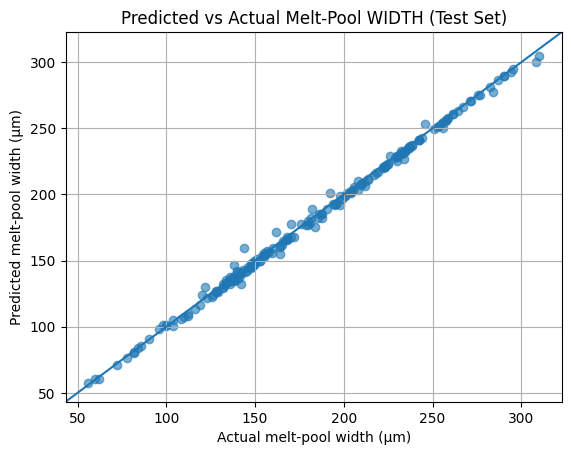

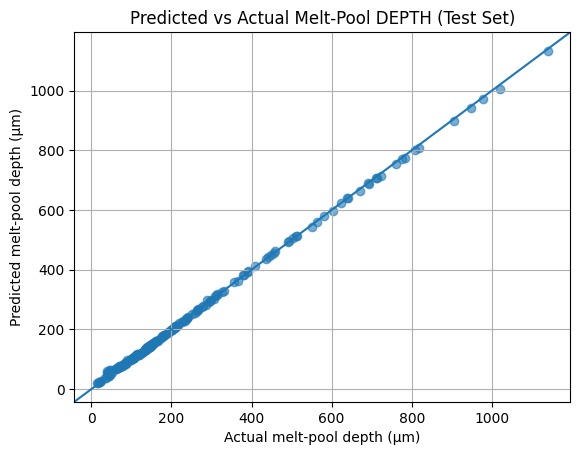

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Rebuild model & load best weights (400-epoch run)
num_numeric_features = X_test_num_t.shape[1]  # should be 6

best_model = MeltPoolSurrogate(
    num_numeric_features=num_numeric_features,
    num_materials=3,
    emb_dim=3,
    hidden_sizes=(64, 64),
    dropout=0.10
).to(device)

best_model.load_state_dict(torch.load("best_meltpool_surrogate_400.pt", map_location=device))
best_model.eval()
print(" Best model reloaded for plotting.")

# 2️⃣ Get predictions on test set
with torch.no_grad():
    preds_test = best_model(X_test_num_t.to(device), mat_id_test_t.to(device))

y_test_np    = y_test_t.cpu().numpy()       # shape (N_test, 2)
preds_test_np = preds_test.cpu().numpy()    # shape (N_test, 2)

true_width  = y_test_np[:, 0]
true_depth  = y_test_np[:, 1]
pred_width  = preds_test_np[:, 0]
pred_depth  = preds_test_np[:, 1]

# Helper to compute plot limits
def get_limits(true, pred):
    vmin = min(true.min(), pred.min())
    vmax = max(true.max(), pred.max())
    # small padding
    pad = 0.05 * (vmax - vmin)
    return vmin - pad, vmax + pad

#  PLOT 1: Width – Predicted vs Actual
plt.figure()
w_min, w_max = get_limits(true_width, pred_width)
plt.scatter(true_width, pred_width, alpha=0.6)
plt.plot([w_min, w_max], [w_min, w_max])  # y = x line
plt.xlim(w_min, w_max)
plt.ylim(w_min, w_max)
plt.xlabel("Actual melt-pool width (µm)")
plt.ylabel("Predicted melt-pool width (µm)")
plt.title("Predicted vs Actual Melt-Pool WIDTH (Test Set)")
plt.grid(True)
plt.show()

#  PLOT 2: Depth – Predicted vs Actual
plt.figure()
d_min, d_max = get_limits(true_depth, pred_depth)
plt.scatter(true_depth, pred_depth, alpha=0.6)
plt.plot([d_min, d_max], [d_min, d_max])  # y = x line
plt.xlim(d_min, d_max)
plt.ylim(d_min, d_max)
plt.xlabel("Actual melt-pool depth (µm)")
plt.ylabel("Predicted melt-pool depth (µm)")
plt.title("Predicted vs Actual Melt-Pool DEPTH (Test Set)")
plt.grid(True)
plt.show()


Train loss length: 240
Val loss length: 240


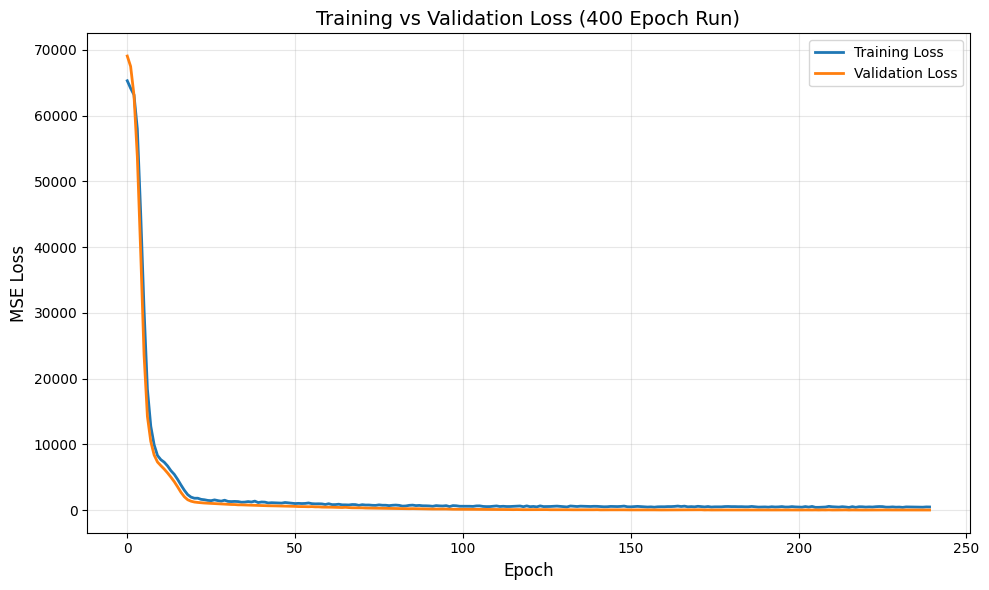

In [20]:
import matplotlib.pyplot as plt

# --- Safety check ---
print("Train loss length:", len(train_losses_400))
print("Val loss length:", len(val_losses_400))

plt.figure(figsize=(10, 6))

plt.plot(train_losses_400, label="Training Loss", linewidth=2)
plt.plot(val_losses_400, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.title("Training vs Validation Loss (400 Epoch Run)", fontsize=14)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


Residual stats:
Width residuals -> mean: -1.2633426 std: 2.891013
Depth residuals -> mean: -0.04949132 std: 4.4741173


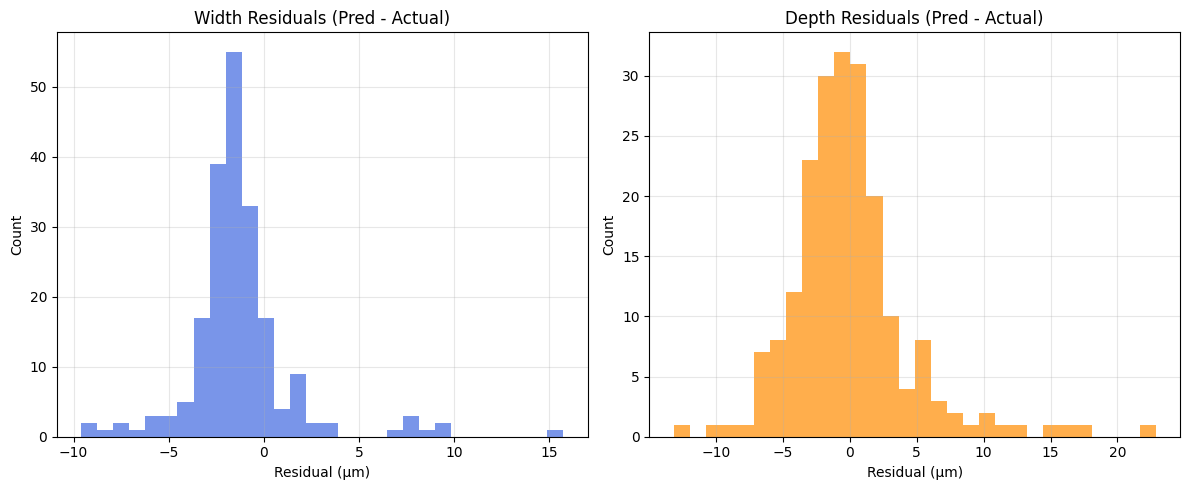

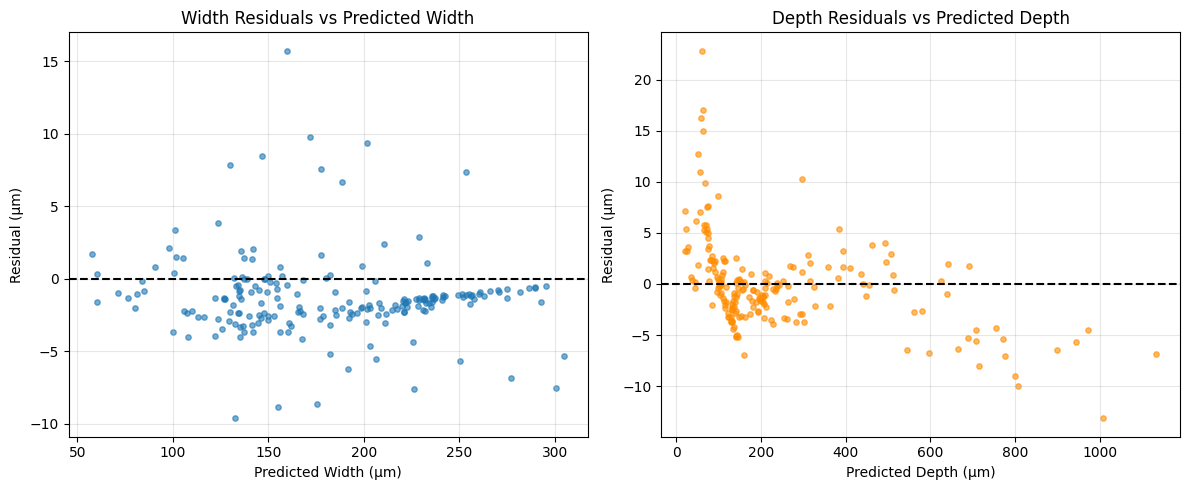

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch


best_model.eval()

with torch.no_grad():
    preds_test = best_model(
        X_test_num_t.to(device),
        mat_id_test_t.to(device)
    ).cpu().numpy()

y_test_np = y_test_t.cpu().numpy()

# Residuals
residuals = preds_test - y_test_np
res_width = residuals[:, 0]
res_depth = residuals[:, 1]

print("Residual stats:")
print("Width residuals -> mean:", np.mean(res_width), "std:", np.std(res_width))
print("Depth residuals -> mean:", np.mean(res_depth), "std:", np.std(res_depth))


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(res_width, bins=30, alpha=0.7, color="royalblue")
plt.title("Width Residuals (Pred - Actual)")
plt.xlabel("Residual (µm)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(res_depth, bins=30, alpha=0.7, color="darkorange")
plt.title("Depth Residuals (Pred - Actual)")
plt.xlabel("Residual (µm)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(preds_test[:, 0], res_width, alpha=0.6, s=15)
plt.axhline(0, color='black', linestyle='--')
plt.title("Width Residuals vs Predicted Width")
plt.xlabel("Predicted Width (µm)")
plt.ylabel("Residual (µm)")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(preds_test[:, 1], res_depth, alpha=0.6, s=15, color="darkorange")
plt.axhline(0, color='black', linestyle='--')
plt.title("Depth Residuals vs Predicted Depth")
plt.xlabel("Predicted Depth (µm)")
plt.ylabel("Residual (µm)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🔍 Material-wise surrogate errors:


,Material,N test samples,MAE Width (µm),RMSE Width (µm),MAE Depth (µm),RMSE Depth (µm)
0,316L,6,3.166861,4.429515,2.886253,4.416564
1,IN718,71,3.234426,4.450335,3.360570,4.251310
2,Ti64,126,1.744909,1.985557,2.870071,4.597990


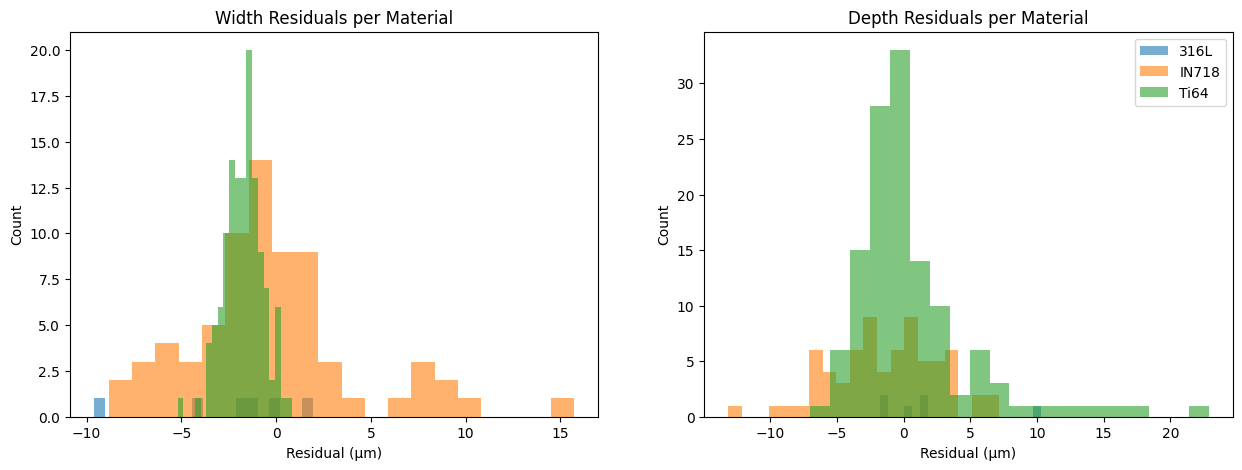

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error

mat_ids_np = mat_id_test_t.cpu().numpy()
true_np    = y_test_t.cpu().numpy()
pred_np    = preds_test            # <-- already numpy, no .cpu()

materials = ["316L", "IN718", "Ti64"]

rows = []

for mat_id, mat_name in enumerate(materials):

    mask = (mat_ids_np == mat_id)
    if mask.sum() == 0:
        continue

    true_m  = true_np[mask]
    pred_m  = pred_np[mask]

    mae_w = mean_absolute_error(true_m[:,0], pred_m[:,0])
    mae_d = mean_absolute_error(true_m[:,1], pred_m[:,1])

    rmse_w = np.sqrt(mean_squared_error(true_m[:,0], pred_m[:,0]))
    rmse_d = np.sqrt(mean_squared_error(true_m[:,1], pred_m[:,1]))

    rows.append([mat_name, mask.sum(), mae_w, rmse_w, mae_d, rmse_d])

df_mat = pd.DataFrame(rows, columns=[
    "Material", "N test samples",
    "MAE Width (µm)", "RMSE Width (µm)",
    "MAE Depth (µm)", "RMSE Depth (µm)"
])

print(" Material-wise surrogate errors:")
display(df_mat)

fig, ax = plt.subplots(1, 2, figsize=(15,5))

for mat_id, mat_name in enumerate(materials):
    mask = (mat_ids_np == mat_id)
    if mask.sum() == 0:
        continue

    res_w = pred_np[mask,0] - true_np[mask,0]
    res_d = pred_np[mask,1] - true_np[mask,1]

    ax[0].hist(res_w, bins=20, alpha=0.6, label=mat_name)
    ax[1].hist(res_d, bins=20, alpha=0.6, label=mat_name)

ax[0].set_title("Width Residuals per Material")
ax[0].set_xlabel("Residual (µm)")
ax[0].set_ylabel("Count")

ax[1].set_title("Depth Residuals per Material")
ax[1].set_xlabel("Residual (µm)")
ax[1].set_ylabel("Count")

plt.legend()
plt.show()


Generating grid for 316L...
Generating grid for IN718...
Generating grid for Ti64...


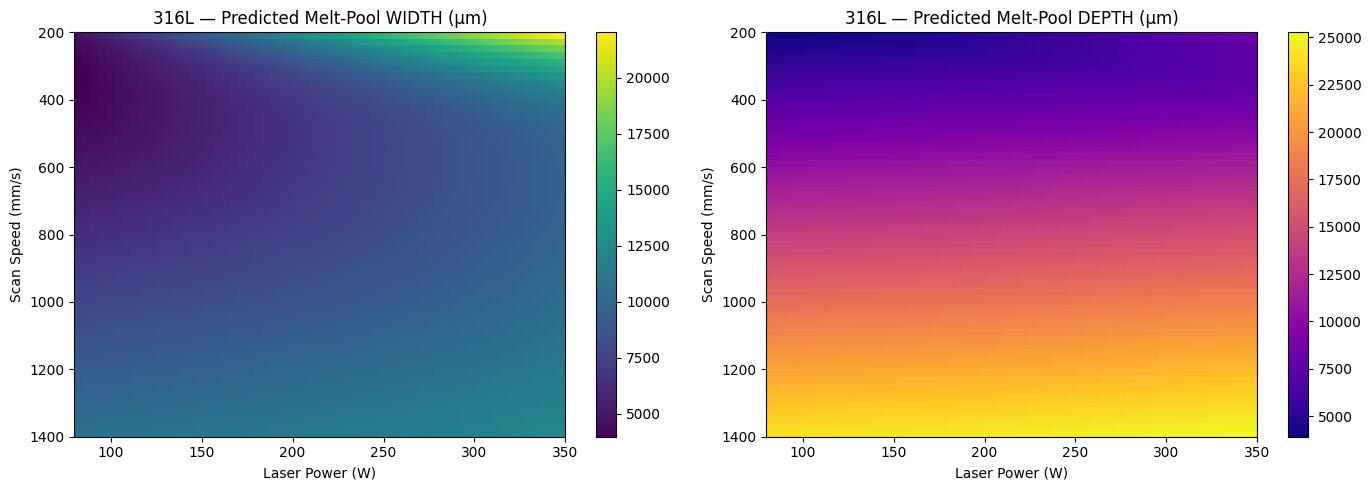

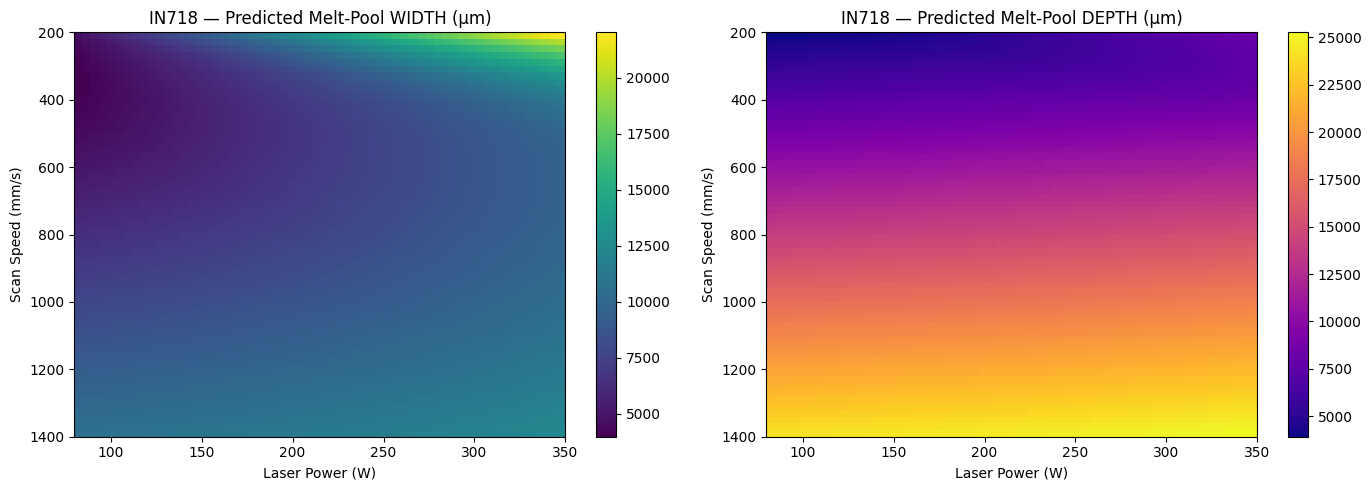

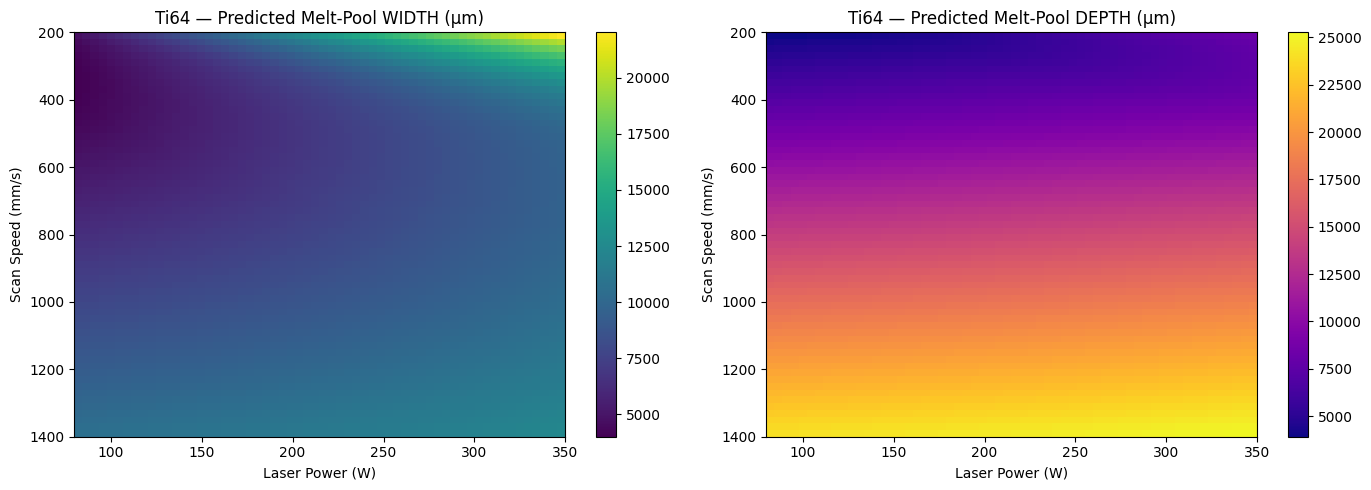

✅ All melt-pool heatmaps generated.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

best_model.eval()

P_values = np.linspace(80, 350, 60)         # Watts
v_values = np.linspace(200, 1400, 60)       # mm/s

PP, VV = np.meshgrid(P_values, v_values)    # grid shape (60, 60)
N = PP.size

# Flatten for batch prediction
P_flat = PP.reshape(-1)
V_flat = VV.reshape(-1)

# Constants from your dataset
h = 0.11
t = 0.04

material_ids = {
    "316L": 0,
    "IN718": 1,
    "Ti64": 2
}

results = {}  # store heatmaps

for mat_name, mat_id in material_ids.items():
    print(f"Generating grid for {mat_name}...")

    # Build numeric input (P, V, h, t, LED, VED)
    LED = P_flat / V_flat
    VED = P_flat / (V_flat * h * t)

    X_grid = np.column_stack([P_flat, V_flat, LED, VED, 
                              np.full(N, h), np.full(N, t)])  # shape (3600, 6)

    X_grid_t = torch.tensor(X_grid, dtype=torch.float32).to(device)
    mat_id_t = torch.tensor(np.full(N, mat_id), dtype=torch.long).to(device)

    # Model prediction
    with torch.no_grad():
        pred = best_model(X_grid_t, mat_id_t).cpu().numpy()

    width_map = pred[:, 0].reshape(PP.shape)
    depth_map = pred[:, 1].reshape(PP.shape)

    results[mat_name] = {
        "width": width_map,
        "depth": depth_map
    }

for mat_name in material_ids.keys():
    width_map = results[mat_name]["width"]
    depth_map = results[mat_name]["depth"]

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    im1 = ax[0].imshow(width_map, extent=[P_values.min(), P_values.max(),
                                         v_values.max(), v_values.min()],
                       aspect='auto', cmap='viridis')
    ax[0].set_title(f"{mat_name} — Predicted Melt-Pool WIDTH (µm)")
    ax[0].set_xlabel("Laser Power (W)")
    ax[0].set_ylabel("Scan Speed (mm/s)")
    fig.colorbar(im1, ax=ax[0])

    im2 = ax[1].imshow(depth_map, extent=[P_values.min(), P_values.max(),
                                         v_values.max(), v_values.min()],
                       aspect='auto', cmap='plasma')
    ax[1].set_title(f"{mat_name} — Predicted Melt-Pool DEPTH (µm)")
    ax[1].set_xlabel("Laser Power (W)")
    ax[1].set_ylabel("Scan Speed (mm/s)")
    fig.colorbar(im2, ax=ax[1])

    plt.tight_layout()
    plt.show()

print(" All melt-pool heatmaps generated.")


Using trained surrogate for power–speed mapping.
Generating melt-pool maps for 316L...
Generating melt-pool maps for IN718...
Generating melt-pool maps for Ti64...


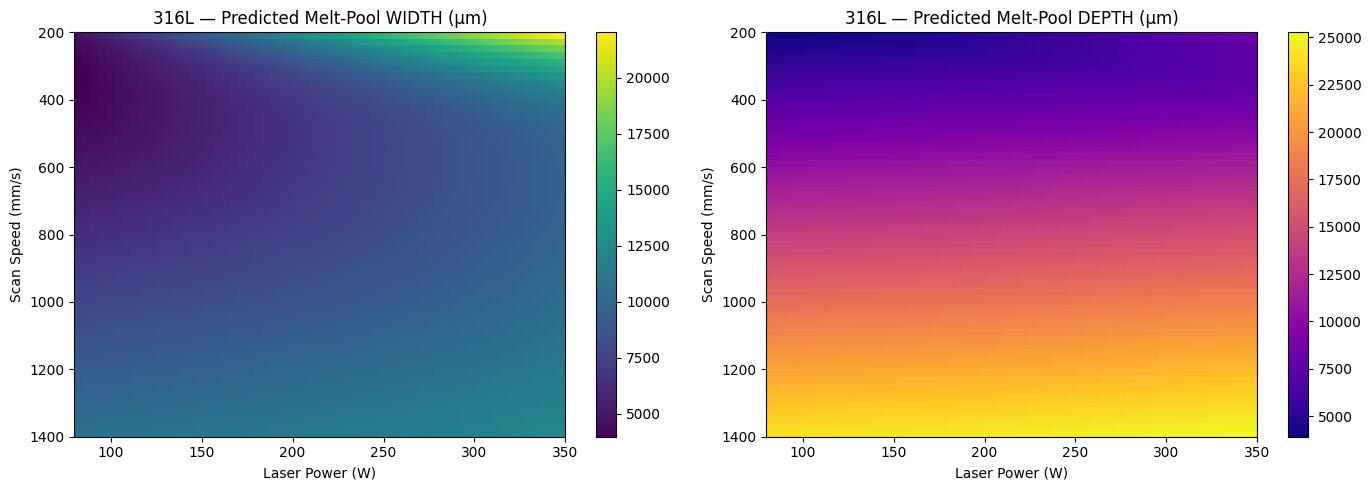

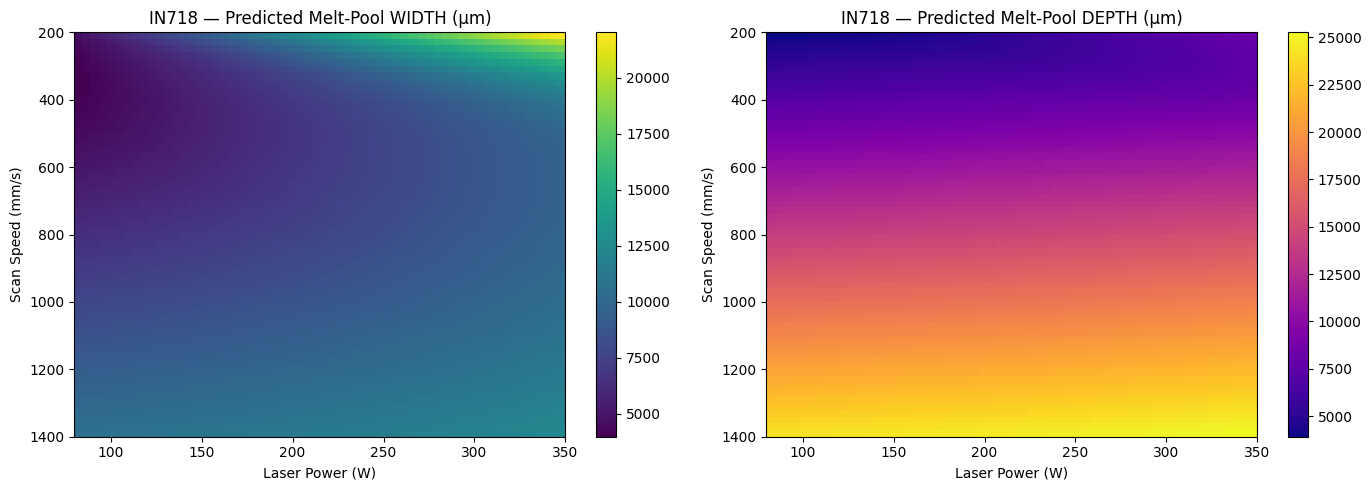

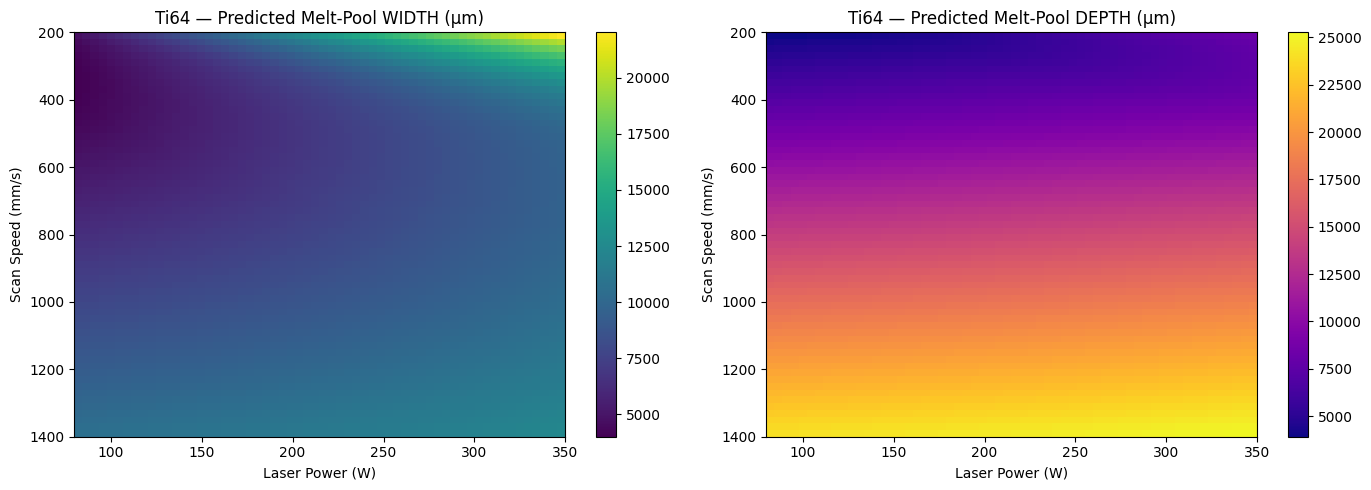

Power–speed melt-pool heatmaps generated for all materials.


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch


best_model.eval()
print("Using trained surrogate for power–speed mapping.")


P_values = np.linspace(80, 350, 60)        # Laser Power (W)
v_values = np.linspace(200, 1400, 60)      # Scan Speed (mm/s)

PP, VV = np.meshgrid(P_values, v_values)   # (60, 60)
N = PP.size                                # 3600 points

# Flatten grid
P_flat = PP.reshape(-1)
V_flat = VV.reshape(-1)


h = 0.11   # Hatch spacing (mm)
t = 0.04   # Layer thickness (mm)


material_ids = {
    "316L": 0,
    "IN718": 1,
    "Ti64": 2
}

results = {}


for mat_name, mat_id in material_ids.items():
    print(f"Generating melt-pool maps for {mat_name}...")

    # Derived physics features
    LED = P_flat / V_flat
    VED = P_flat / (V_flat * h * t)

    # Numeric feature vector (must match training order)
    X_grid = np.column_stack([
        P_flat,
        V_flat,
        LED,
        VED,
        np.full(N, h),
        np.full(N, t)
    ])

    X_grid_t = torch.tensor(X_grid, dtype=torch.float32).to(device)
    mat_id_t = torch.tensor(np.full(N, mat_id), dtype=torch.long).to(device)

    with torch.no_grad():
        preds = best_model(X_grid_t, mat_id_t).cpu().numpy()

    results[mat_name] = {
        "width": preds[:, 0].reshape(PP.shape),
        "depth": preds[:, 1].reshape(PP.shape)
    }


for mat_name in material_ids.keys():
    width_map = results[mat_name]["width"]
    depth_map = results[mat_name]["depth"]

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    im1 = ax[0].imshow(
        width_map,
        extent=[P_values.min(), P_values.max(), v_values.max(), v_values.min()],
        aspect="auto",
        cmap="viridis"
    )
    ax[0].set_title(f"{mat_name} — Predicted Melt-Pool WIDTH (µm)")
    ax[0].set_xlabel("Laser Power (W)")
    ax[0].set_ylabel("Scan Speed (mm/s)")
    fig.colorbar(im1, ax=ax[0])

    im2 = ax[1].imshow(
        depth_map,
        extent=[P_values.min(), P_values.max(), v_values.max(), v_values.min()],
        aspect="auto",
        cmap="plasma"
    )
    ax[1].set_title(f"{mat_name} — Predicted Melt-Pool DEPTH (µm)")
    ax[1].set_xlabel("Laser Power (W)")
    ax[1].set_ylabel("Scan Speed (mm/s)")
    fig.colorbar(im2, ax=ax[1])

    plt.tight_layout()
    plt.show()

print("Power–speed melt-pool heatmaps generated for all materials.")


In [25]:
import numpy as np
import pandas as pd

# Ensure model is in eval mode
best_model.eval()

# Predict on test set
with torch.no_grad():
    preds_test = best_model(
        X_test_num_t.to(device),
        mat_id_test_t.to(device)
    ).cpu().numpy()

# True values
y_true = y_test_t.cpu().numpy()

# Errors
width_err = preds_test[:, 0] - y_true[:, 0]
depth_err = preds_test[:, 1] - y_true[:, 1]

# Absolute errors
width_abs = np.abs(width_err)
depth_abs = np.abs(depth_err)

# Build DataFrame for analysis
err_df = pd.DataFrame({
    "material_id": mat_id_test_t.cpu().numpy(),
    "width_abs_err": width_abs,
    "depth_abs_err": depth_abs
})

# Map material names
material_map = {0: "316L", 1: "IN718", 2: "Ti64"}
err_df["material"] = err_df["material_id"].map(material_map)

err_df.head()


,material_id,width_abs_err,depth_abs_err,material
0,2,0.780304,1.095078,Ti64
1,2,1.603912,1.083176,Ti64
2,2,2.273453,0.211494,Ti64
3,2,1.577271,8.670425,Ti64
4,1,8.499481,2.628967,IN718


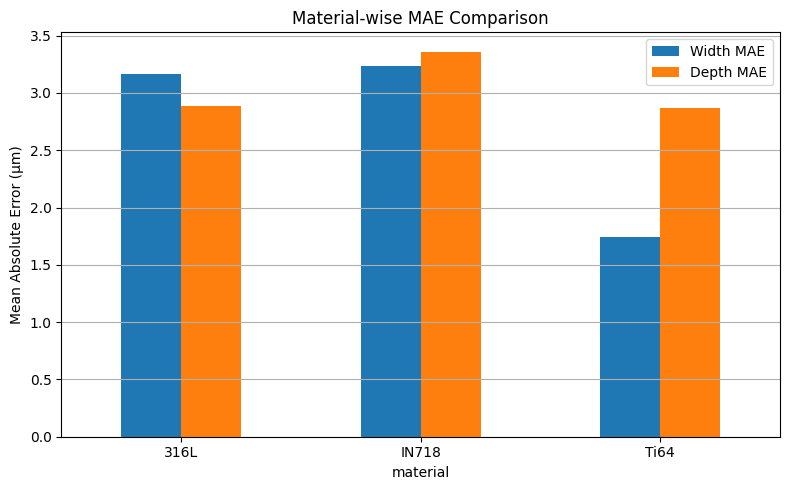

In [26]:
import matplotlib.pyplot as plt

# Compute MAE per material
mae_summary = err_df.groupby("material")[["width_abs_err", "depth_abs_err"]].mean()

# Plot
mae_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Mean Absolute Error (µm)")
plt.title("Material-wise MAE Comparison")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(["Width MAE", "Depth MAE"])
plt.tight_layout()
plt.show()


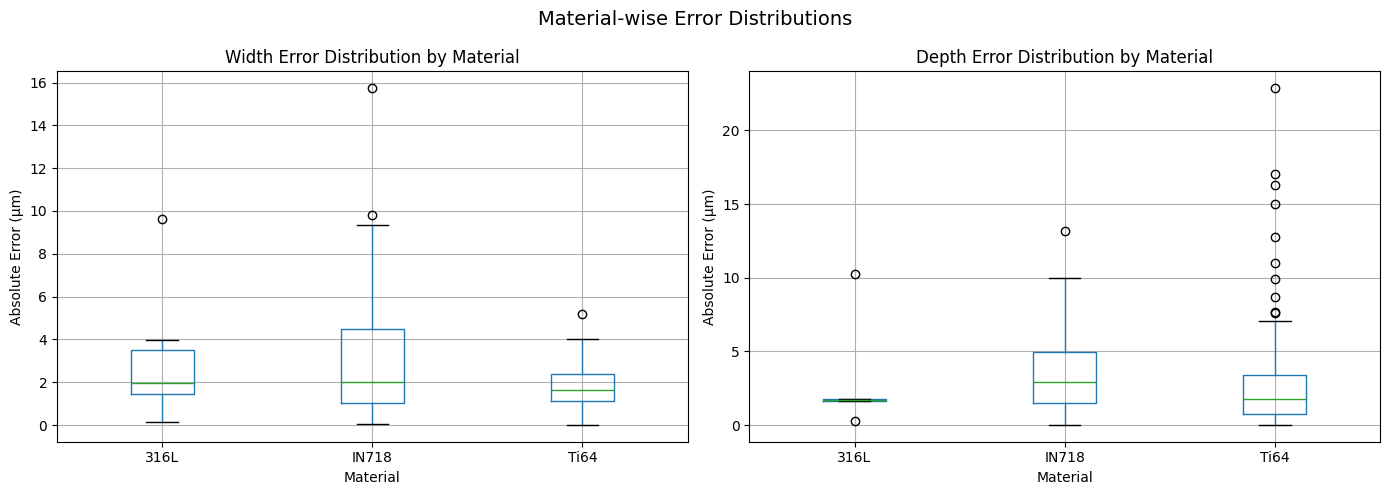

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Width error boxplot
err_df.boxplot(
    column="width_abs_err",
    by="material",
    ax=axes[0],
    grid=True
)
axes[0].set_title("Width Error Distribution by Material")
axes[0].set_ylabel("Absolute Error (µm)")
axes[0].set_xlabel("Material")

# Depth error boxplot
err_df.boxplot(
    column="depth_abs_err",
    by="material",
    ax=axes[1],
    grid=True
)
axes[1].set_title("Depth Error Distribution by Material")
axes[1].set_ylabel("Absolute Error (µm)")
axes[1].set_xlabel("Material")

plt.suptitle("Material-wise Error Distributions", fontsize=14)
plt.tight_layout()
plt.show()
